<a href="https://colab.research.google.com/github/knelson-lab/A04-knn07001/blob/main/A04_xAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A04: Model Interpretability (xAI)
-----------------------------------
**Your Name Here:**

You previously worked with this dataset on the 'Sampling' notebooks. Now, you will try to interpret the model!

You will build a classification model of your choice (you may use SMOTE or not - I'm not testing how good your model is for this assignment, just that you know how to interpret the model!). You must do some form of autoML or grid search...

The target variable is Loan_Status (thanks Ahmend for the heads-up!)

Then you will:
* Print the Top 5 features (using permutation importance with 20 repeats) in a box plot.
* Create the partial dependence plots for the top 5 features (you may opt to use the num_grid_points argument). Customize the plots so that the Y axis is consistent on each of the five plots.
* Write five meaningful bullets about what you see in the plots. Does anything surprise you? What do the X and Y axis mean in each plot?
  * Optional: Any issues with correlated predictors (read here for a cool way on how to address this: https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance_multicollinear.html)?

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import  MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, mean_absolute_error
#from sklearn.externals import joblib
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance

from imblearn.over_sampling import SMOTE, SMOTENC
from pycebox.ice import ice, ice_plot
from collections import Counter
from tpot import TPOTClassifier
#import time
import joblib

In [48]:
#https://drive.google.com/file/d/1CppeqGbiBzX61jx56gcXyGGDNEeLlJ-W/view?usp=share_link
!gdown 1CppeqGbiBzX61jx56gcXyGGDNEeLlJ-W

Downloading...
From: https://drive.google.com/uc?id=1CppeqGbiBzX61jx56gcXyGGDNEeLlJ-W
To: c:\Users\kevin\OneDrive\Documents\GitHub\A04-knn07001\train_loan_imbalanced.csv

  0%|          | 0.00/38.0k [00:00<?, ?B/s]
100%|██████████| 38.0k/38.0k [00:00<00:00, 2.81MB/s]


In [3]:
# Updated file path as student repository does not have content folder
df = pd.read_csv('train_loan_imbalanced.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Build a classification model

In [4]:
# Drop unnecessary Loan ID column
df.drop('Loan_ID', axis = 1, inplace = True)

# Identify any NA values in dataset
df.isna().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
# Drop rows with NA values
df.dropna(inplace = True, axis = 0)

# Check balance of response variable 
df['Loan_Status'].value_counts()

Loan_Status
Y    332
N    148
Name: count, dtype: int64

In [6]:
# Use label encoder to avoid problems with logistic regression  
LE = LabelEncoder()
df['Loan_Status'] = LE.fit_transform(df['Loan_Status'])

In [28]:
# Create y variable for response
y = df['Loan_Status']
# Create x variable for predictors
X = df.drop('Loan_Status', axis = 1)

tmp = X.select_dtypes(include = ["object_"])
# Get column headers for categorical predictors  
cols = tmp.columns

X_encoded = X.copy()
for col in cols:
    X_encoded[col] = LE.fit_transform(X_encoded[col].astype(str))

# Create training and test partitions prior to applying SMOTENC sampling
seed = 123 
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size = 0.2, random_state = seed, stratify = y)

# Scale training and test predictors to be between 0 and 1 
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Use SMOTE to balance dataset with numerical predictors
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)
Counter(y_res)

Counter({1: 266, 0: 266})

In [10]:
tpot = TPOTClassifier(
    generations = 1,
    cv = 3,
    random_state = seed
)
tpot.fit(X_res, y_res)

c:\Users\kevin\AppData\Local\Programs\Python\Python310\lib\site-packages\tpot\tpot_estimator\estimator.py:458: UserWarning: Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.
  warnings.warn("Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.")
Generation: 100%|██████████| 1/1 [01:17<00:00, 77.90s/it]
c:\Users\kevin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,search_space,<tpot.search_...001E8C03829B0>
,scorers,['roc_auc_ovr']
,scorers_weights,[1]
,cv,3
,other_objective_functions,[]
,other_objective_functions_weights,[]
,objective_function_names,None
,bigger_is_better,True
,categorical_features,None
,memory,None
,preprocessing,False


In [ ]:
y_pred = tpot.predict(X_test)
mae = accuracy_score(y_test, y_pred)

print("Best pipeline test MAE: %.3f" % mae)
print("Best pipeline test neg(MAE) (for comparison with TPOT scoring): %.3f" % (-mae))

print("\nBest pipeline found by TPOT:\n")
print(tpot.fitted_pipeline_)



Best pipeline test MAE: 0.750
Best pipeline test neg(MAE) (for comparison with TPOT scoring): -0.750

Best pipeline found by TPOT:

Pipeline(steps=[('normalizer', Normalizer(norm='l1')),
                ('passthrough', Passthrough()),
                ('featureunion-1',
                 FeatureUnion(transformer_list=[('featureunion',
                                                 FeatureUnion(transformer_list=[('powertransformer',
                                                                                 PowerTransformer())])),
                                                ('passthrough',
                                                 Passthrough())])),
                ('featureunion-2',
                 FeatureUnion(transformer_list=[('skiptransformer',
                                                 SkipTransformer()),
                                                ('passthrough',
                                                 Passthrough())])),
                ('rando

In [12]:
# Save best pipeline to disk
model_path = 'tpot_loanStatus_pipeline.joblib'
joblib.dump(tpot.fitted_pipeline_, model_path)
print(f"\nSaved best pipeline to {model_path}")


Saved best pipeline to tpot_loanStatus_pipeline.joblib


Print the Top 5 features (using permutation importance with 20 repeats) in a box plot.


C:\Users\kevin\AppData\Local\Temp\ipykernel_21120\1001119739.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(result.importances[perm_sorted_top5].T, vert = False,


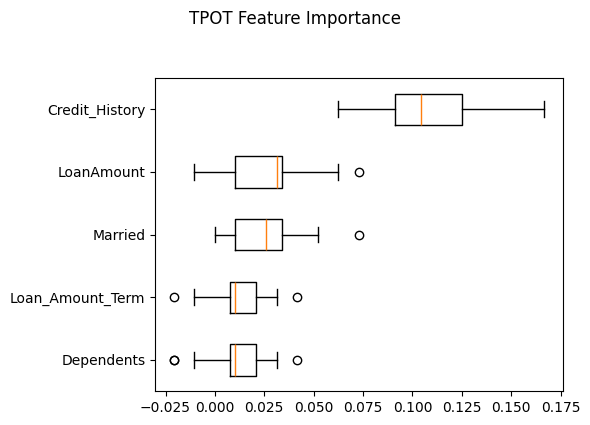

In [ ]:
clf = TPOTClassifier() 

result = permutation_importance(tpot.fitted_pipeline_, X_test, y_test, n_repeats = 20, random_state = 42, scoring = 'accuracy')
perm_sorted_idx = result.importances_mean.argsort()
perm_sorted_top5 = perm_sorted_idx[-5 : ]

fig, ax1 = plt.subplots(1, 1, figsize = (6, 4))
ax1.boxplot(result.importances[perm_sorted_top5].T, vert = False,
            labels = X.columns[perm_sorted_top5])
fig.suptitle('TPOT Feature Importance', y = 1.05) 
fig.tight_layout()
plt.show()

Create the partial dependence plots for the top 5 features (you may opt to use the num_grid_points argument). Customize the plots so that the Y axis is consistent on each of the five plots.

In [ ]:
X_res_df = pd.DataFrame(X_res, columns = X.columns)

<class 'pandas.core.frame.DataFrame'>
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']


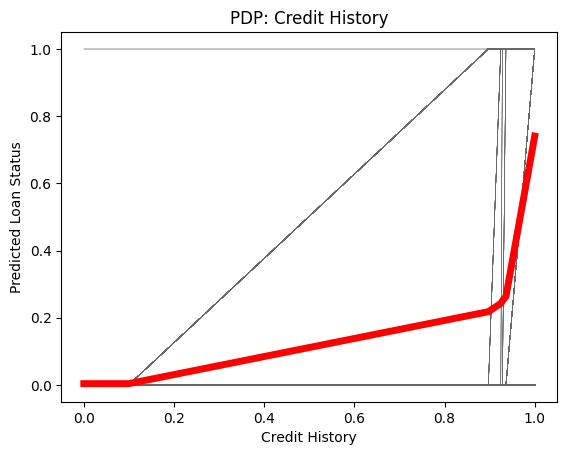

In [ ]:
tmpdf = ice(data = X_res_df, 
            column = 'Credit_History',
            predict = tpot.fitted_pipeline_.predict)

ice_plot(tmpdf, c = 'dimgray', linewidth = 0.3, plot_pdp = True,
         pdp_kwargs = {'linewidth': 5, 'color':'red'})
plt.title('PDP: Credit History')
plt.ylabel('Predicted Loan Status')
plt.xlabel('Credit History');
plt.show()

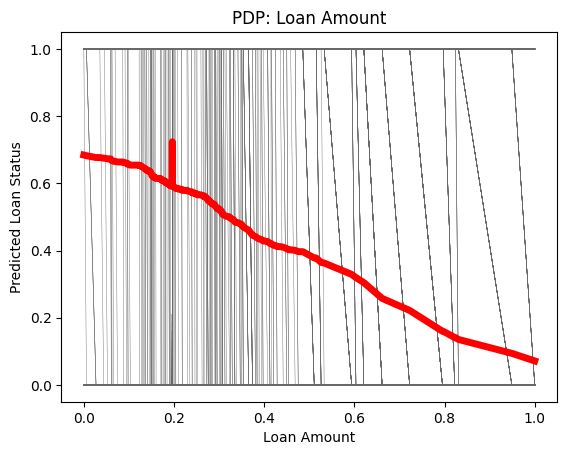

In [36]:
tmpdf = ice(data = X_res_df, 
            column = 'LoanAmount',
            predict = tpot.fitted_pipeline_.predict)

ice_plot(tmpdf, c = 'dimgray', linewidth = 0.3, plot_pdp = True,
         pdp_kwargs = {'linewidth': 5, 'color':'red'})
plt.title('PDP: Loan Amount')
plt.ylabel('Predicted Loan Status')
plt.xlabel('Loan Amount');
plt.show()

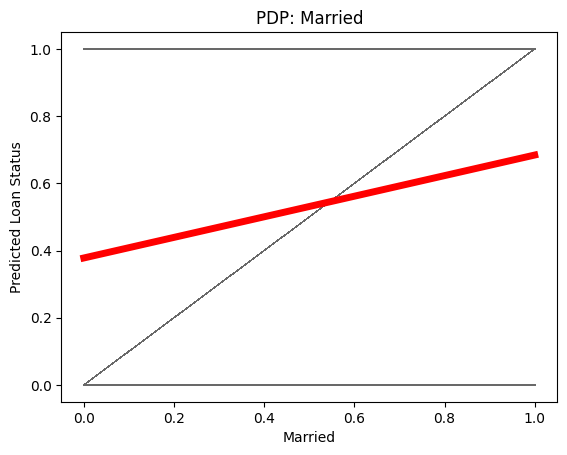

In [ ]:
tmpdf = ice(data = X_res_df, 
            column = 'Married',
            predict = tpot.fitted_pipeline_.predict,
            num_grid_points = 2)

ice_plot(tmpdf, c = 'dimgray', linewidth = 0.3, plot_pdp = True,
         pdp_kwargs = {'linewidth': 5, 'color':'red'})
plt.title('PDP: Married')
plt.ylabel('Predicted Loan Status')
plt.xlabel('Married');
plt.show()

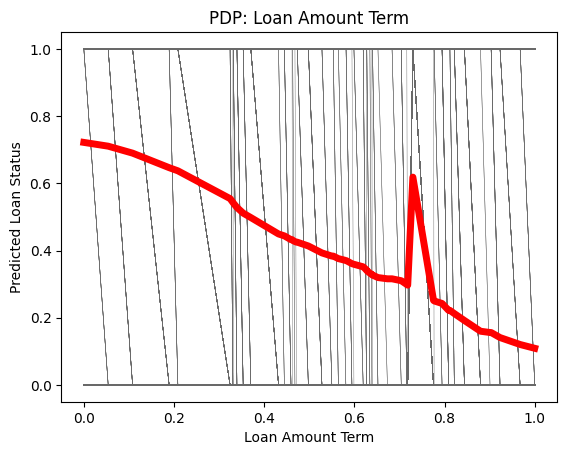

In [39]:
tmpdf = ice(data = X_res_df, 
            column = 'Loan_Amount_Term',
            predict = tpot.fitted_pipeline_.predict)

ice_plot(tmpdf, c = 'dimgray', linewidth = 0.3, plot_pdp = True,
         pdp_kwargs = {'linewidth': 5, 'color':'red'})
plt.title('PDP: Loan Amount Term')
plt.ylabel('Predicted Loan Status')
plt.xlabel('Loan Amount Term');
plt.show()

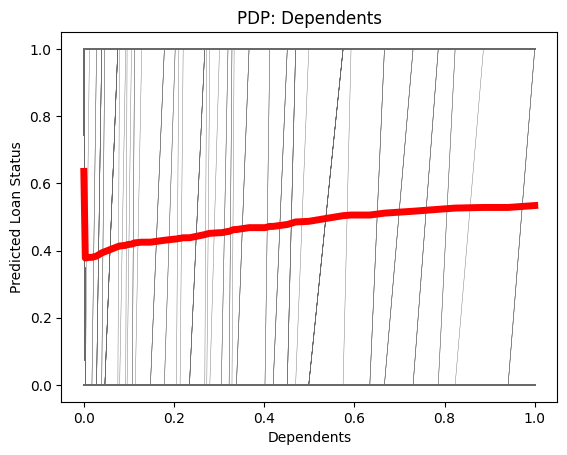

In [40]:
tmpdf = ice(data = X_res_df, 
            column = 'Dependents',
            predict = tpot.fitted_pipeline_.predict)

ice_plot(tmpdf, c = 'dimgray', linewidth = 0.3, plot_pdp = True,
         pdp_kwargs = {'linewidth': 5, 'color':'red'})
plt.title('PDP: Dependents')
plt.ylabel('Predicted Loan Status')
plt.xlabel('Dependents');
plt.show()

Write five meaningful bullets about what you see in the plots. Does anything surprise you? What do the X and Y axis mean in each plot?
- The permutation importance plots are the easiest to understand from the plots above. Credit history being the most important variable makes sense as that is the baseline number typically used for loans. 
- Loan amount and marriage being the next two most important variables are also intuitive as the former changes the risk of the loan and the latter is an indicator for security as it means there are two people cosigning on the loan typically. 
- The x-axis on the permutation importance plot indicates the decrease in MAE for the model when that variable is removed. 
- The x-axis on the partial dependence plots indicate the values that this variable can hold in our model. The results showed are scaled from 0-1 and I'm wondering based on looking at these whether the unscaled numbers would be a better representation. 
- The y-axis on the partial dependence plots indicate how our predictions will change based on the value that our predictor variable takes on. 
